# Countries Clustring

In [ ]:
import kagglehub
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

## 1. Load Dataset

In [ ]:
# path = kagglehub.dataset_download("rohan0301/unsupervised-learning-on-country-data")
data = pd.read_csv("/kaggle/input/unsupervised-learning-on-country-data/Country-data.csv")

## 2. Exploratory and Data Analysis (EDA)

In [ ]:
data.head()

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 167 entries, 0 to 166
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   country     167 non-null    object 
 1   child_mort  167 non-null    float64
 2   exports     167 non-null    float64
 3   health      167 non-null    float64
 4   imports     167 non-null    float64
 5   income      167 non-null    int64  
 6   inflation   167 non-null    float64
 7   life_expec  167 non-null    float64
 8   total_fer   167 non-null    float64
 9   gdpp        167 non-null    int64  
dtypes: float64(7), int64(2), object(1)
memory usage: 13.2+ KB


In [ ]:
data.describe()

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
count,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000
mean,38.270060,41.108976,6.815689,46.890215,17144.688623,7.781832,70.555689,2.947964,12964.155689
std,40.328931,27.412010,2.746837,24.209589,19278.067698,10.570704,8.893172,1.513848,18328.704809
min,2.600000,0.109000,1.810000,0.065900,609.000000,-4.210000,32.100000,1.150000,231.000000
25%,8.250000,23.800000,4.920000,30.200000,3355.000000,1.810000,65.300000,1.795000,1330.000000
50%,19.300000,35.000000,6.320000,43.300000,9960.000000,5.390000,73.100000,2.410000,4660.000000
75%,62.100000,51.350000,8.600000,58.750000,22800.000000,10.750000,76.800000,3.880000,14050.000000
max,208.000000,200.000000,17.900000,174.000000,125000.000000,104.000000,82.800000,7.490000,105000.000000


In [ ]:
data.isna().sum()

,0
country,0
child_mort,0
exports,0
health,0
imports,0
income,0
inflation,0
life_expec,0
total_fer,0
gdpp,0


In [ ]:
data.duplicated().value_counts()

,count
False,167


## 3. Features

In [ ]:
X_train = data.drop("country", axis=1)

## 4. Precossecing

In [ ]:
preprocessor = ColumnTransformer(transformers=[("scaling", StandardScaler(), X_train.columns)],remainder="passthrough")
X_train_processed = preprocessor.fit_transform(X_train)

## 5. Elbow method

In [ ]:
all_inertia = {}
for i in range(2,16):
  model = KMeans(n_clusters=i,init='k-means++',random_state=33)
  model.fit(X_train_processed)

  all_inertia[i] = model.inertia_

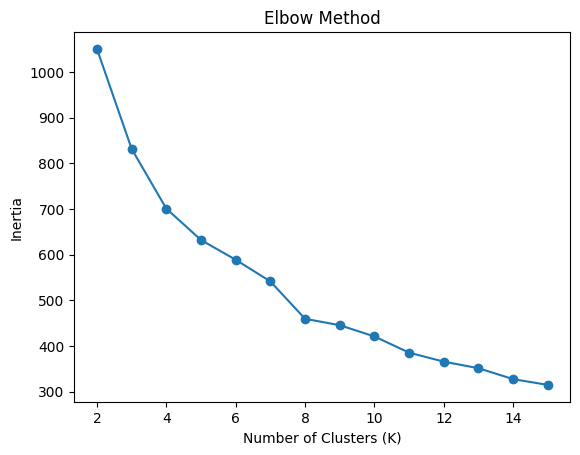

In [ ]:
plt.plot(all_inertia.keys(), all_inertia.values(), marker="o")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()

## 6. Silhouette Score

In [ ]:
for k in range(2, 11):
    model = KMeans(n_clusters=k, random_state=42)
    labels = model.fit_predict(X_train_processed)

    score = silhouette_score(X_train_processed, labels)

    print(f"K={k}, Silhouette Score={score:.3f}")

K=2, Silhouette Score=0.266
K=3, Silhouette Score=0.286
K=4, Silhouette Score=0.288
K=5, Silhouette Score=0.301
K=6, Silhouette Score=0.236
K=7, Silhouette Score=0.248
K=8, Silhouette Score=0.202
K=9, Silhouette Score=0.192
K=10, Silhouette Score=0.196


## 7.  Model Training

In [ ]:
model = KMeans(n_clusters=5, init='k-means++', random_state=33)

In [ ]:
model.fit(X_train_processed)

KMeans(n_clusters=5, random_state=33)

In [ ]:
score = silhouette_score(X_train_processed, model.labels_)

print("Silhouette Score:", score)

Silhouette Score: 0.2248021596445697


In [ ]:
pd.DataFrame(model.cluster_centers_, columns=X_train.columns, index=(list("ABCDE")))

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
A,-0.828609,0.172621,0.859190,-0.296373,1.462275,-0.478189,1.107649,-0.763681,1.661902
B,-0.495794,0.285142,0.020170,0.533397,-0.226394,-0.366747,0.244768,-0.496304,-0.311425
C,1.431317,-0.481812,-0.164652,-0.167858,-0.721863,0.389040,-1.306885,1.417711,-0.621447
D,-0.849003,4.935673,-0.008163,4.548058,2.439542,-0.504206,1.226824,-1.038863,2.440797
E,-0.244439,-0.393988,-0.544325,-0.726964,-0.199990,0.515134,0.204876,-0.265330,-0.361635


In [ ]:
print("Number of examples in each cluster")
pd.Series(model.labels_).value_counts().sort_index()

Number of examples in each cluster


,count
0,30
1,54
2,44
3,3
4,36
